<a href="https://colab.research.google.com/github/elean23/2025-webinar-ml-with-python/blob/main/Module5Capsule1_abiertaUGR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![header_slide_abiertaugr_bigdata](https://i.imgur.com/qqwdHLo.png)
## Module 5.1 Classification: what, why, and how?

**Author**:

*By* Prof. Alberto Fernández Hilario

Full Professor at the University of Granada, Andalusian Interuniversity Institute on Data Science and Computational Intelligence (DasCI)

## Brief Instructions

### Reminder: Introduction to NoteBook

The *Jupyter* (Python) notebook is an approach that combines blocks of text (like this one) along with blocks or cells of code. The great advantage of this type of cells is their interactivity, as they can be executed to check the results directly on them.

**Very important**: the order of the instructions (code blocks) is fundamental, so each cell of this notebook must be executed sequentially. In case of omitting any of them, the program may throw an error (an exit block will be displayed with a red message in English), so you should start from the beginning in case of doubt. To make this step easier, you can go to the "Run Environment" menu and click on "Run previous".

Go for it!

Click on the "play" button on the left side of each code cell. Lines starting with a hashtag (#) are comments and do not affect the execution of the programme.

You can also click on each cell and do "*ctrl+enter*" (*cmd+enter* on Mac).

When the first of the blocks is executed, the following message will appear:

"Warning: This notebook was not created by Google.

*The creator of this notebook is \@go.ugr.es. It may request access to your data stored in Google or read data and credentials from other sessions. Please review the source code before running this notebook. If you have any questions, please contact the creator of this workbook by sending an email to \<author>@go.ugr.es. "*

Don't worry, you will have to trust the contents of the Notebook and click on "*Run anyway*". All the code runs on an external compute server and will not affect your computer at all. No information or credentials will be requested, so you will be able to continue the course safely.

Each time you run a block, you will see the output just below it. The information is usually always the last instruction, along with any `print()` (print command) in the code.

##**INDEX**

In this *NoteBook*:

1. We present the task of classification in machine learning.
2. We will describe how to measure the quality of classification models and discuss their most important metrics.
3. We show an example of how to apply the learning and validation process to a dataset.

Contents:
1. [Introduction to classification.](#sec:clasificacion)  
2. [Measuring the quality of machine learning classification models.](#sec:eval)   
3. [Complete examples in a case study.](#sec:dataset)  
4. [Bibliographical references.](#sec:biblio)

## **1. INTRODUCTION TO CLASSIFICATION**

The classification learning task focuses on creating what is known as a ‘*discriminant*’. This term refers to a function that can distinguish between the output classes or labels represented in the problem. This discriminant function will use the values of the input variables that define the case study or problem being worked on. This generates a division (e.g., a simple straight line) that splits the dataset into two or more sections, creating zones that identify each of the classes.

The figure below shows two types of classification discriminant functions: a simple linear one (a straight line) and a more complex one (a polynomial function). Both are used to determine the areas of space that belong to each of the classes of the same two-variable problem.

![Decision borderline of a lineal discriminant function in classification](https://i.imgur.com/f6dqpWP.png)

![Decision borderline of a polinomial discriminant function in classification](https://i.imgur.com/zT0mh0b.png)

It is important to note that the discriminant functions that comprise the classification model have a dual purpose. Their main task is to serve as predictive tools for new examples. Additionally, an added advantage is that they allow the extraction of underlying knowledge from the data by means of the model representation itself.

This will depend on the so-called *interpretability* of the model. In other words, whether its representation is simple or if it is closer to human cognition and semantics and therefore, explains the data in a similar way as a person would. For example, if a reduced genetic panel model is used to teach a model to distinguish patients with or without a specific pathology, it provides us with knowledge of the main genes to study to identify patients at risk. This information would allow researchers to work on inhibitors for these genes to help identify useful and effective treatments.

![Interpretable models than explain its working procedure](https://i.imgur.com/FSERM3z.png)

There are different types of *discriminant functions* which identify different paradigms or classification models. These include linear discriminants such as the one from the figure above (a simple linear function between the input variables), a set of rules (a list of attribute-value conjunctions), or an environment or neighborhood in the training data set (similarity between samples). There are also more complex systems such as so-called neural networks, or support vector machines.

The first group (linear models and rules) are called ‘white box’ models or ‘transparent systems’ because they allow direct interpretation by the user and are therefore often preferred when a high level of confidence in the model is required. The second type (neural networks) are known as ‘black box’ models and tend to achieve a higher hit rate, although it is not trivial to explain why they produce a particular output.

In this module, we will analyze some of the best known and most representative classification paradigms of both systems.

## **2. MEASURING THE QUALITY OF CLASSIFICATION MODELS IN MACHINE LEARNING**

All machine learning methodologies or techniques require an evaluation function or metric to quantitatively estimate the generalizability of the model, that is, how well it will perform predictions on new data.

In the context of classification, the most common of these metrics is known as the prediction accuracy. However, many other metrics are available for this purpose and these functions may not necessarily identify a simple numerical value. The key point here is that the choice of a particular metric should be guided by our ultimate goal.

This objective might simply be to maximize the number of correct instances or to study a particularly interesting  class. For example, in an automated diagnostic system, giving a false negative prediction (discharging a sick patient) involves more risk than the opposite (identifying a healthy patient as sick).


### **2.1 Confusion matrix**

A ‘*confusion matrix*’ is used as a starting point to define any evaluation metrics in the classification. This is nothing more than a table that crosses the predictions with the actual classification (*ground truth*). Thus, it allows hits and misses to be separated by pairs of classes, giving more insight into which classes are more difficult to classify with the model or which ones tend to ‘mix’.

If we consider a binary classification problem that must evaluate a positive (`pos`) and negative (`neg`) class, as well as a learned classifier, as shown in the figure below, the types of predictions would be:

<img src="https://i.imgur.com/jqbfLUY.png" width="400" alt="Matriz de confusión para dos clases">

Now we will set up a very simple example of a confusion matrix using two lists of values. One corresponds to the actual output and the other to the model prediction, denoted as `y_actual` and `y_pred`, respectively. Running the following code snippet will display the matrix


In [18]:
from sklearn.metrics import confusion_matrix

y_actual = ["pos", "neg", "pos", "neg", "neg", "pos"] #actual labels
y_pred = ["pos", "pos", "pos", "neg", "neg", "pos"] #ML predictions

confusion_matrix(y_actual, y_pred, labels=["pos", "neg"])

array([[3, 0],
       [1, 2]])

Note that there was a single "miss", in this case associated with the second `neg` (negative) class.



### **2.2 Accuracy metric**

Each cell in the above matrix is identified as follows:

- True Positive (TP): positive instance, predicted positive.
- False Positive (FP): negative instance, predicted positive.
- True Negative (TN): negative instance, predicted negative.
- False Negative (FN): positive instance, predicted negative.

The first of the above metrics represents the accuracy rate and is obtained using the following formula:

$
accuracy = \frac{TP+TN}{(TP+FP+TN+FN)}
$

which, as shown, indicates the proportion of correctly classified instances from the total number of instances.


Next, we check the accuracy of the model obtained in the previous example in terms of distinguishing between negative (`neg`) and positive (`pos`) classes. This is achieved by using the `accuracy_score` function whose parameters are the lists or arrays of real output and predicted values, respectively. The value obtained is a ratio, although the accuracy  is very often expressed as a percentage by multiplying it by 100.


In [19]:
from sklearn.metrics import accuracy_score

accuracy_score(y_actual, y_pred)

0.8333333333333334

In our case, the value obtained is quite high at almost 85% correct. As previously indicated, this is because only 1 out of 6 instances was missed. To observe the behavior of this metric, the differences with a less accurate prediction metric (`y_pred2`) is then checked:

In [20]:
#Fails half of the time...
y_pred2 = ["neg", "pos", "pos", "neg", "neg", "neg"]
#For convenience, the initial list of values is remembered:
y_actual = ["pos", "neg", "pos", "neg", "neg", "pos"] #actual labels.

accuracy_score(y_actual, y_pred2)

0.5

In this case, the quality of the model drops to 50% correct. Thus, as we determined, the *accuracy metric* quantifies the ratio of well-classified instances with respect to the total, regardless of the class to which they belong.


### **2.3 Individual metrics per class**

Sometimes it is much more interesting to evaluate the accuracy separately for each of the classes. This is necessary when, as in many biomedical studies, one of these classes is more relevant. For example, the focus on the need for early medical attention in the detection of neurological diseases.

For this reason, individual metrics such as the following are available:

- *Sensitivity*, *recall*, or true positive rate ($TP_{rate}$). It is obtained as $sensitivity = \frac{TP}{TP+FN}$
- *Specificity* or true negative rate ($TN_{rate}$). It is obtained as $specificity = \frac{TN}{TN+FP}$
- Precision. Swhich refers to the ratio of correctly identified positive examples with respect to the total number of instances and tries to reduce the number of ‘false alarms’, is obtained as $precision = \frac{TP}{TP+FP}$

Because these individual values do not provide an overview of the quality of the model, these metrics are very often summarized or aggregated, for example, by using the *F-measure metric* which aggregates *precision* and *recall*:

\begin{equation}
F1 = 2*\frac{precision*recall}{precision+recall}
\end{equation}

The next step will be to analyze the model performance in the prediction of negative versus positive values for the above two examples, according to the individual metrics. For this, we must indicate which class should be considered positive (`pos`) by using the `pos_label` parameter.

In [21]:
from sklearn.metrics import recall_score, precision_score, f1_score

# First prediction
recall = recall_score(y_actual, y_pred, pos_label="pos")
precision = precision_score(y_actual, y_pred, pos_label="pos")
f1 = f1_score(y_actual, y_pred,pos_label="pos")

print("Recall {} | Precision {} | F1 {}".format(recall,precision,f1))

# Second prediction
recall = recall_score(y_actual, y_pred2,pos_label="pos")
precision = precision_score(y_actual, y_pred2,pos_label="pos")
f1 = f1_score(y_actual, y_pred2,pos_label="pos")

print("Recall {} | Precision {} | F1 {}".format(recall,precision,f1))


Recall 1.0 | Precision 0.75 | F1 0.8571428571428571
Recall 0.3333333333333333 | Precision 0.5 | F1 0.4


Having to individually complete this query for each of the measures is a bit tedious, so you might be wondering it there’s a function to summarize the main ones?

Of course, the answer is yes—it’s called `classification_report` and the syntax for its use is shown in the next block.

In [22]:
from sklearn.metrics import classification_report

labels = ['pos', 'neg']

print("Analysing model #1 (best behavior)")
print(classification_report(y_actual, y_pred, target_names=labels))

print("Analysting model #2 (worst behaviour)")
print(classification_report(y_actual, y_pred2, target_names=labels))

Analysing model #1 (best behavior)
              precision    recall  f1-score   support

         pos       1.00      0.67      0.80         3
         neg       0.75      1.00      0.86         3

    accuracy                           0.83         6
   macro avg       0.88      0.83      0.83         6
weighted avg       0.88      0.83      0.83         6

Analysting model #2 (worst behaviour)
              precision    recall  f1-score   support

         pos       0.50      0.67      0.57         3
         neg       0.50      0.33      0.40         3

    accuracy                           0.50         6
   macro avg       0.50      0.50      0.49         6
weighted avg       0.50      0.50      0.49         6



For each of the two summaries generated above, the following information is observed::

- First (rows 1 and 2), the precision, recall, f1, and number of samples (*support*) are shown for each of the classes contained in the problem (`pos` and `neg` in our case).
- Second, the accuracy metrics are indicated after a blank space:
  - Overall accuracy (under the f1 column).
  - “Macro average” accuracy, averaging the unweighted mean per class label.
  - “Weighted average” accuracy, averaging the weighted mean support per label.

Note that in the binary classification, the recall of the positive class is also known as ‘sensitivity’, while the recall of the negative class is known as the ‘specificity’.

### **2.4 Graphical metrics: Area Under the Receiver Operating Characteristic curve (AUC)**

In the last step, the area under the receiver operating characteristic (ROC) curve (AUC) metric numerically and visually summarizes the quality of the models.

To calculate this metric, the output confidence level of each prediction (i.e., how ‘confident’ the classifier is of the decision it has made) is used instead of the confusion matrix. This value can be used as a threshold to force the classifier to make the prediction as a ‘positive class’ whenever its confidence exceeds the cut-off. By default, this threshold value is set to 0.5, meaning that the classifier is at least 50% sure that the actual class is positive. However, this value can be lowered, resulting in more instances predicted as positive (possibly with more false positives), or increased (having the opposite result).


The ROC curve represents how the sensitivity values ($TP_{rate}$) and false positive ratio ($FP_{rate} = 1-TN_{rate}$) vary if the threshold is changed. Logically, if the threshold is set to 0.0, then all the instances will be directly classified as positive (upper right corner of the graph). If set to 1.0, the instances would only be classified as positive when there is absolute (100%) certainty or confidence (x-axis intercept). Each possible intermediate value represents a value on the curve and implies a different balance between the $TP_{rate}$ and $FP_{rate}$.

Because the positive class probability is used, this graphical approach works only for binary-type classifications (a maximum of two classes).


In the following example, relatively complicated code was used to represent this graph (ROC curve). However, you can ignore the technical programming details for the moment because the same result will be obtained later using a single line of code.

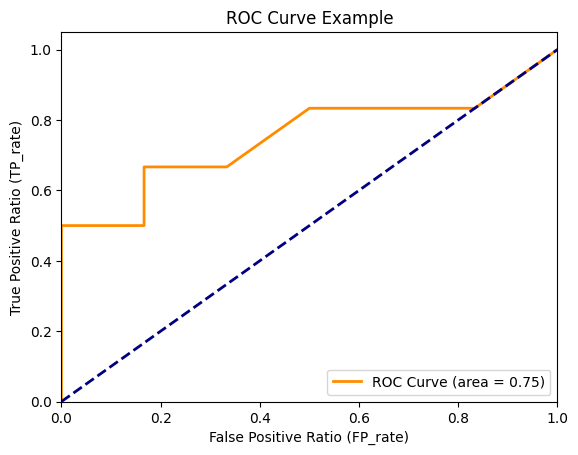

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve,roc_auc_score

#Salidas
y_actual = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
y_probs = np.array([0.1, 0.2, 0.5, 0.4, 0.7, 0.35, 0.8, 0.65, 1.0, 0.4, 0.75, 0.1])
#for "y_pred" (now called y_probs) instead of labels, we use probabilities

#Computation of performance metrics
roc_auc = roc_auc_score(y_actual, y_probs)
fpr, tpr, _ = roc_curve(y_actual, y_probs)

#We plot the figure
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC Curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Ratio (FP_rate)')
plt.ylabel('True Positive Ratio (TP_rate)')
plt.title('ROC Curve Example')
plt.legend(loc="lower right")
plt.show()

In any ROC curve, the curve should ideally be close to the upper left corner (a high sensitivity or $TP_{rate}$ and a low $FP_{rate}$). A curve above the diagonal line implies that the predictions are close to random.

In addition to the AUC plot itself, a numerical value associated with the integral (area) of the curve is also calculated. As you may have deduced, calculation of the AUC metric is not trivial, but fortunately most machine learning software already incorporates it. In any case, if the ‘probability prediction’ values are ignored and therefore, there is only one point on the ROC curve (the one associated with the default threshold of 0.5), the formula that calculates the AUC would be as follows:

\begin{equation}
AUC = \frac{1 + TP_{rate} - FP_{rate}}{2}
\end{equation}

As an oddity, the AUC at a single point and the accuracy measure are identical when the same number of instances of the positive and negative classes are available.


## **3. A COMPLETE CASE STUDY EXAMPLE OF THE USE OF OMICS DATA TO DETECT MELANOMA.**

In this section we present an overview of the process of creating classification models with machine learning algorithms.

To do so, first we must retrieve the dataset containing the omics information for the melanoma case study. In the remaining sections we will discover the general process of knowledge extraction in the field of data science, namely, loading the dataset, partitioning during training and testing, learning models, and validating the quality of the models.




### **3.1 Retrieving data from the gene expression matrix**


As already indicated at the beginning of this course, genomic alterations are of vital importance in many fields of bioinformatics. The procedure for their study usually starts with the collection of different tissue or blood samples. Cellular information is then obtained from these samples by leveraging a sequencing procedure such as next generation sequencing (NGS) to obtain the expression values of the different genes comprising the DNA in the samples.

Thus, a data set with a number of rows equal to the number of sequenced genes (input variables) and a number of columns equal to the number of collected samples (instances) is usually obtained. Finally, in clinical studies, external annotations are made on each sample. These additional variables are useful and relevant both at the levels of prediction (as output variables) and description (as input variables), and can even allow simpler interpretation of the results obtained.


In this section of the course, the selected case study deals with the prediction of **cutaneous melanoma** by considering two biologically relevant classes. On the one hand are samples whose most expressed genes are usually associated with cells, molecules, or proteins that apparently ‘inhibit’ melanoma, generically referred to as ‘*immune*’ labels. On the other hand, are the samples whose most highly expressed genes may be related to microphthalmia-associated transcription factors, more simply referred to as ‘*MITF*’ labels.


Throughout this module about **classification**, we will use a modified version of the original dataset. Specifically, we performed preprocessing to simplify the problem with respect to both the number of input variables and the information contained in the instances. We would also like to emphasize that we transposed the structure of the input data file (where the gene expression matrix is stored) in order to follow the standard machine learning notation in which each row is an instance and each column is a variable.

### **3.2 Loading data and exploratory analysis**

We have already seen and used this initial procedure and so we only need to repeat this process (see Modules 2 and 4). The first 5 samples are printed at the end of the code snippet to confirm that it has correctly loaded.

In [24]:
import pandas as pd

#We load the expression matrix omics data from a shared file on Google Drive.
gene_exp_immune = pd.read_csv('https://drive.google.com/uc?id=1PYzEIdmnfjOnBpPDIFBE9hL1Lkj_OBCk',index_col=0)
#We load the clinical variable corresponding to the labels "immune" vs. "MITF-low".
clinical_info_immune = pd.read_csv('https://drive.google.com/uc?id=1hHQfcvrFa5Jds-9tW_X4sHjKpYKdii9s',index_col=0)

X, y = gene_exp_immune, clinical_info_immune

#We print the first 5 samples of the dataset.
X.head()

,COL2A1,RXRG,CCL19,SSX1,CST2,PRSS33,CDH2,SCUBE2,TMPRSS13,TRPM8,...,UBASH3A,GBP4,PRF1,PTK6,PCDHB2,GSDMA,DIO2,PLIN1,NCF1C,SLC7A11
0,-1.431141,-7.845756,0.665118,-1.409304,-2.537396,-1.676281,1.529957,-0.895042,-0.298778,5.091742,...,-0.659997,-1.469602,-0.570793,1.047635,-2.068966,-0.202828,-0.506767,1.285256,-0.901222,2.483020
1,-0.424374,-8.352423,0.386055,-2.846138,-0.685105,0.339787,-3.488043,-0.584982,5.679815,-1.117879,...,0.190202,-0.282190,0.375094,0.261662,3.356282,2.028145,-2.399010,-1.152801,0.662490,-2.914991
2,11.014251,0.415549,-1.633781,0.315442,-0.662332,-0.498761,0.535811,-0.467456,-2.818738,1.731049,...,-0.816305,-0.316202,-1.153745,-2.284201,-1.761597,-0.746975,-2.988195,-1.976877,-1.400889,-2.266779
3,-1.180446,-8.187415,-1.958023,5.061146,-2.603744,-0.666706,0.456460,-4.609624,-1.713164,-3.880876,...,0.214344,-0.327110,0.476764,1.153275,-0.337649,-1.006765,-2.686648,-1.329148,0.055994,-2.652313
4,0.816312,-1.189303,4.837235,4.972176,-2.963715,-2.665721,-0.268042,-1.740607,0.011610,-4.107467,...,3.352734,2.145368,3.358865,-2.324389,-1.741669,0.734312,-1.649316,6.284688,1.450729,1.131275


Whenever you start working with a new dataset, it is useful to understand its structure (i.e., the number of instances, input variables, descriptive statistics, and the distribution of classes, etc.). This is considered the exploration and analysis stage while in this current module we are implementing the data exploration and analysis stage.

First, the structure of the dataset and classes (output variables) and their distribution are observed.

In [25]:
print("Number of instances and number of variables:",X.shape)
print("Class values:",pd.unique(y['RNASEQ-CLUSTER_CONSENHIER']))
print("Number of instances for each class:\n",y.value_counts())

Number of instances and number of variables: (336, 50)
Class values: ['immune' 'MITF-low']
Number of instances for each class:
 RNASEQ-CLUSTER_CONSENHIER
MITF-low                     168
immune                       168
Name: count, dtype: int64


We must verify that we are working with a reduced dataset with respect to the original one, specifically, with 50 genes or input variables. In addition, we must check that the ratio of instances per class has been forced to maintain a 1:1 ratio. Finally, some of the main descriptive statistics can be observed, usually for the top 10 genes.

In [26]:
#The "describe" command displays the main statistics (first 10 variables only).
X[X.columns[0:10]].describe()

,COL2A1,RXRG,CCL19,SSX1,CST2,PRSS33,CDH2,SCUBE2,TMPRSS13,TRPM8
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000
mean,0.851833,-0.719944,1.136670,0.455719,0.562422,0.243546,0.173262,-0.144176,0.026026,0.435880
std,3.225967,3.171022,3.112834,3.059409,3.024017,2.848285,2.612762,2.617039,2.294357,2.740942
min,-2.453544,-9.460513,-6.670597,-3.316233,-2.963715,-3.826060,-6.937990,-6.293538,-4.181460,-4.974098
25%,-0.996501,-1.466714,-0.157164,-2.445496,-1.696510,-2.353053,-1.664596,-2.238180,-1.760676,-1.518327
50%,-0.366554,0.408615,1.615818,0.019864,-0.429073,0.293924,0.576447,0.039506,-0.320967,0.550273
75%,1.433984,1.352582,3.148308,2.615407,2.031879,2.039151,2.096088,1.905312,1.204806,2.181670
max,13.077674,3.452661,7.279227,8.045333,12.186303,9.439966,5.199115,5.527684,7.381040,7.094981


### **3.3 Create data partitions in the training and test sets**

For simplicity, we will use default *hold-out* validation. For more details on this, see Module 3, Capsule 2 (Supervised learning).

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

print("Number of training instances: {}; y test: {}".format(len(X_train),len(X_test)))

Number of training instances: 252; y test: 84


### **3.4 Training and machine learning model predictions**

Among the different classification techniques available, the *k-nearest neighbors (KNN) classifier* is popular and easy to understand. This technique is one of the simplest learning strategies (in fact, it does not actually learn): it searches the training dataset for instances whose variables are most similar to a new, unknown instance, and assigns them the most frequent class among all these ‘*neighbors*’. We will provide more details on the specific operation of this algorithm in the following sections of this module.

For now, a basic notion of this algorithm and its interface (how to interact with it) is sufficient. This is because it is common to all the supervised learning algorithms implemented in *scikit-learn*.

To generate and learn our model, it must be ‘instantiated’ (an object of type `estimator` must be created) and subsequently trained (the `fit()` method must be called up). Remember that we have to include both the input instances (`X`) and their output values (`y`) to build the model.

The steps required to achieve this are shown in the following code snippet:


In [28]:
from sklearn.neighbors import KNeighborsClassifier # load function from the library
import warnings
warnings.filterwarnings("ignore") # ignore this line

knn = KNeighborsClassifier() # instantiate the model (default parameters)
knn.fit(X_train, y_train) # most important: we train the model
print(knn.get_params())

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}


The output shown in the previous block is the classifier configuration created with the parameters assigned according to the default scikit-learn configuration: the number of neighbors (`n_neighbors`), distance (`metric`), and weights (`weights`), etc.


### **3.5 Computation of the quality of the generated model**

One of the stages during machine learning is to check if we have achieved the desired quality results, for which test partitioning will be used. In scikit-learn, the following default methods are available to perform the prediction or obtain the quality metrics directly for all supervised-type estimators:

-	`model.predict()`: given a model that is already trained, this metric predicts the class of a new data set. This method accepts a single parameter: the new test data `X_test` (e.g. `model.predict(X_test)`) and returns the predicted class for a given instance of the dataset.
- `model.predict_proba()`: for classification problems, some algorithms also contain this method. It returns the probability that each instance belongs to each of the classes. The class with the maximum probability would match the label predicted by `model.predict()`; it is primarily used to generate the ROC curve and measure the AUC.
- `model.score()+: almost all classifiers implement a method called `score`. For classifiers, this method is associated with the percentage of appropriately classified examples (accuracy).



El siguiente bloque de código utiliza el algoritmo *kNN* aprendido en el bloque anterior para generar predicciones sobre el conjunto de test (variable ```X_test```).

In [29]:
y_pred = knn.predict(X_test) # predicción de cada etiqueta

# imprimimos la etiqueta calculada para los 10 primeros datos de X_test
print(y_pred[:10])

['MITF-low' 'MITF-low' 'MITF-low' 'MITF-low' 'MITF-low' 'MITF-low'
 'MITF-low' 'MITF-low' 'MITF-low' 'MITF-low']


The next block of code uses the KNN algorithm that we saw in the previous block to generate predictions on the test set (variable `X_test`).

The accuracy score can now be calculated using the corresponding function from the scikit-learn library, as described in Section 2 of this NoteBook. To do this, it is sufficient to compare the actual output `y_test` with the prediction made by `y_pred` from kNN.


In [30]:
from sklearn.metrics import accuracy_score

acc_score = accuracy_score(y_test, y_pred)
print(acc_score)

0.6428571428571429


In this case, the accuracy is not very high. We can see how many samples were misclassified by creating a confusion matrix, as already described in Section 2 above.

In this matrix, the rows represent the actual class, and the columns represent the predicted class; the more instances on the diagonal, the better the score achieved.

In [31]:
from sklearn.metrics import confusion_matrix
m = confusion_matrix(y_test, y_pred)
print(m)

[[43  1]
 [29 11]]


### **3.6 Cross validation made simple**

Validation of the model obtained in the learning phase is essential. Among the alternatives for this process, the most appropriate is cross-validation of $k$ partitions. Because this procedure is very common in machine learning, flexible functions that use very little code are available for it.

The `sklearn.model_selection` package contains all the functions related to model validation. Although we already explained how to generate the partitions ‘by hand’ in Module 3, the simplest way is to use the `cross_val_score` function, which receives an estimator (classifier) and a dataset and undertakes the whole process automatically. In other words, it returns an `array` (a list-like data type) with the predictions obtained for each partition.


In [32]:
import numpy as np
from sklearn.model_selection import cross_val_score

scores = cross_val_score(knn, X, y) #default 5 partitions

print(scores) #the individual values of each partition
print(np.mean(scores)) #the overall average success rate


[0.61764706 0.59701493 0.59701493 0.62686567 0.68656716]
0.6250219490781387


By default, `cross_val_score` uses `StratifiedKFold` for sorting. As explained in Module 3, the stratified partitioning type ensures that the proportion of examples per class is respected in each partition.

As a reminder, for a binary dataset with an unbalanced classification (i.e., if 90% of the instances call into the `neg` class), this would mean the same number of instances (90% in this case) in each partition should call into the `neg` class.


### **3.7 Visualization of the model quality**

First, it is very important to use the confusion matrix to check the output of the model in each of the classes (as already shown above) to check whether there is any bias towards one of the classes. In this case, it is more convenient to generate graphs to visualize this content in a report.

For this task, we can use the `plot_confusion_matrix()` method, as shown in the following example



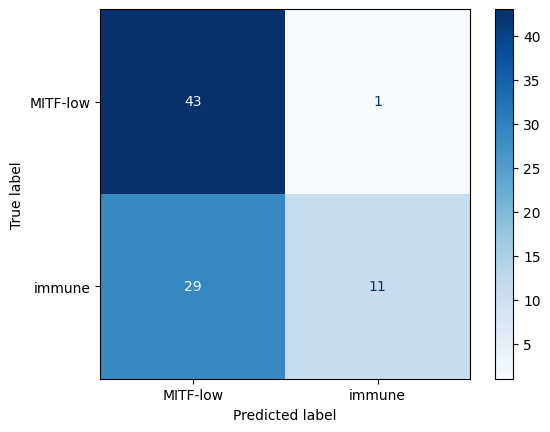

In [33]:
from sklearn import metrics
import matplotlib.pyplot as plt

#the cmap parameter to use a blue colour map to be comfortable to the eye.
metrics.ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test,cmap=plt.cm.Blues)

The AUC value can also be calculated using the `roc_auc_score`. To do this, it is essential to use the `predict_proba()` method in the classifier because you need to generate the probability values, not the output classes.

Finally, the ROC curve can be plotted with the `plot_roc_curve` function. In this case the method receives three parameters: the classifier, set of instances, and list of output values.

The value of AUC for kNN is 0.7664772727272727


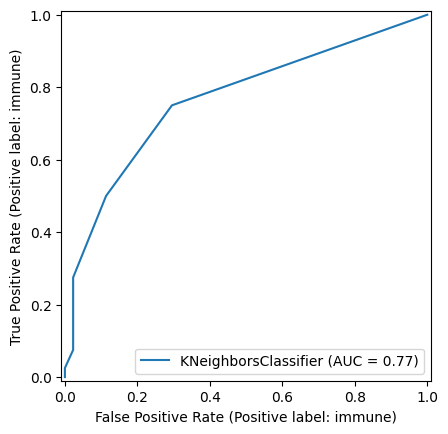

In [34]:
from sklearn import metrics

y_prob = knn.predict_proba(X_test)

auc_knn = metrics.roc_auc_score(y_test, y_prob[:,1])
print("The value of AUC for kNN is", auc_knn)

metrics.RocCurveDisplay.from_estimator(knn, X_test, y_test) #plot the curve

## **BIBLIOGRAPHICAL REFERENCES**

-	Han, J., Kamber, M., Pei, J. (2011). Data Mining: Concepts and Techniques. San Francisco, CA, USA: Morgan Kaufmann Publishers. ISBN: 0123814790, 9780123814791
-	Witten, I. H., Frank, E., Hall, M. A., Pal, C. J. (2017). Data mining: practical machine learning tools and techniques. Amsterdam; London: Morgan Kaufmann. ISBN: 9780128042915 0128042915
- Scikit-Learn: Metrics and scoring: quantifying the quality of predictions https://scikit-learn.org/stable/modules/model_evaluation.html (visitado el 25 de Junio de 2020).

### **Additional references**

-	Alpaydin, E. (2016). Machine Learning: The New AI. MIT Press. ISBN: 9780262529518
- Towards Data Science: Various ways to evaluate a machine learning model’s performance https://towardsdatascience.com/various-ways-to-evaluate-a-machine-learning-models-performance-230449055f15 (visitado el 25 de Junio de 2020).



<div class="alert alert-block alert-success">

MOOC Machine Learning and Big Data for Bioinformatics (2nd edition)   
http://abierta.ugr.es     
    
![CC](https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc-nd.png)
</div>    